<a href="https://colab.research.google.com/github/pallavigeddam/cs207-section5-team4-project/blob/main/Pallavi_Stock_Classification_Full_YahooDataSet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stock Movement Classification

Predicting next-day price direction for SPY, NVDA, MU, and TSLA as a 5-class problem.
This notebook runs the full pipeline once (data, 25 features, look-ahead-safe target, split,
EDA), then trains two models on the same data: a multinomial logistic regression baseline and
a TensorFlow LSTM. It also compares daily vs weekly vs monthly prediction. Run the setup cell
once per Colab session, then Run All. A GPU runtime is recommended for the LSTM.

In [1]:
# Setup: install yfinance. No API keys needed, Yahoo Finance is free and open.
!pip install -q yfinance

import os
print("yfinance installed. No API keys required.")

yfinance installed. No API keys required.


## 1. Setup and Configuration

Everything tunable is in one place. Changing the symbols, the date range, or the
number of classes is a one-line edit here.

In [2]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# Team-standard settings (same symbols and window as Neil and Vansh so notebooks merge cleanly)
SYMBOLS    = ["SPY", "NVDA", "MU", "TSLA"]
START, END = "2016-06-20", "2026-06-20"   # about 10 years of daily bars
TRAIN_FRAC = 0.70                          # 70% train, 15% val, 15% test (chronological)
VAL_FRAC   = 0.15
N_CLASSES  = 5                             # 5-class quantile target (team decision)
FLAT_K     = 0.33                          # only used if N_CLASSES == 3

USE_SYNTHETIC = False                      # set True to run offline without network access
RANDOM_STATE  = 42
# LSTM knobs
WINDOW     = 20      # lookback: days per sequence (~1 month)
EPOCHS     = 30      # max passes; early stopping usually halts sooner
BATCH_SIZE = 64

np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")
print("Config loaded. Symbols:", SYMBOLS)

Config loaded. Symbols: ['SPY', 'NVDA', 'MU', 'TSLA']


In [3]:
def _synthetic_prices(symbols, start, end):
    # Offline fallback only. Makes fake but realistic-looking price paths so the
    # notebook can run end to end without network access. Not used for real results.
    dates = pd.bdate_range(start=start, end=end)
    n = len(dates); out = {}
    betas = {"SPY": 1.0, "NVDA": 1.7, "MU": 1.4, "TSLA": 1.8}
    for s in symbols:
        r = np.random.normal(4e-4, 0.012 * betas.get(s, 1.2), n)
        close = 100 * np.exp(np.cumsum(r))
        hi = close * (1 + np.abs(np.random.normal(0, 0.006, n)))
        lo = close * (1 - np.abs(np.random.normal(0, 0.006, n)))
        op = lo + (hi - lo) * np.random.rand(n)
        v  = np.random.lognormal(16, 0.4, n)
        df = pd.DataFrame({"open": op, "high": hi, "low": lo, "close": close, "volume": v}, index=dates)
        df.index.name = "date"; df["symbol"] = s
        out[s] = df
    return out

## 2. Data Acquisition

We pull daily OHLCV bars for each symbol from Yahoo Finance using yfinance.
`auto_adjust=True` automatically handles all stock splits and dividends, so the
NVDA 10-for-1 split in June 2024 and the TSLA 3-for-1 split in August 2022 are
corrected and do not appear as fake one-day crashes.
We keep each symbol in its own frame so a rolling feature can never blend one
ticker's prices into another's.

In [4]:
import yfinance as yf

def download_prices(symbols, start, end):
    # Pull split and dividend adjusted daily bars from Yahoo Finance.
    # auto_adjust=True handles all corporate actions automatically.
    out = {}
    for s in symbols:
        df = yf.download(s, start=start, end=end, auto_adjust=True, progress=False)
        # yfinance returns a MultiIndex when downloading one symbol, flatten it
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = [c[0].lower() for c in df.columns]
        else:
            df.columns = [c.lower() for c in df.columns]
        df.index = pd.DatetimeIndex(df.index).tz_localize(None).normalize()
        df.index.name = "date"
        df = df[["open", "high", "low", "close", "volume"]].copy()
        df["symbol"] = s
        out[s] = df
        print(f"  {s:5s} {len(df):>5d} rows | {df.index.min().date()} to {df.index.max().date()}")
    return out

if USE_SYNTHETIC:
    raw = _synthetic_prices(SYMBOLS, START, END)
    print("USING SYNTHETIC DATA (offline mode)")
else:
    raw = download_prices(SYMBOLS, START, END)
    print("Downloaded real data from Yahoo Finance (auto_adjust=True)")

rows_before = sum(raw[s].shape[0] for s in SYMBOLS)
print("Total raw rows across all symbols:", rows_before)
raw["SPY"].head()

  SPY    2514 rows | 2016-06-20 to 2026-06-18
  NVDA   2514 rows | 2016-06-20 to 2026-06-18
  MU     2514 rows | 2016-06-20 to 2026-06-18
  TSLA   2514 rows | 2016-06-20 to 2026-06-18
Downloaded real data from Yahoo Finance (auto_adjust=True)
Total raw rows across all symbols: 10056


,open,high,low,close,volume,symbol
date,,,,,,
2016-06-20,177.875607,178.548533,176.964160,177.049347,82789600,SPY
2016-06-21,177.432688,177.960808,176.989741,177.551941,72461700,SPY
2016-06-22,177.730847,178.454893,177.117540,177.262360,95560500,SPY
2016-06-23,178.718942,179.621862,178.258968,179.570755,102731400,SPY
2016-06-24,173.454765,179.604859,172.679612,173.122559,333444400,SPY


## 3. Feature Engineering

All features are built per symbol and are **stationary**: returns, ratios, and bounded
indicators instead of raw price or volume levels. Raw price climbs steadily over 10 years,
so the scaler trained on cheap 2016 prices would not match expensive 2025 prices. Returns
and ratios stay on the same scale throughout.

We start with 32 candidate features then apply dimensionality reduction, dropping 7 that
are redundant with others in the same group. The final set is 25 features:

- Momentum at 4 horizons (10/20/50/200 days). Dropped 30 and 100 day as they carry no
  unique information between their neighbours.
- Price-to-MA distance for 4 windows (10/20/50/200). Dropped 100 day, same reason.
- MA cross (50/200 golden/death cross signal).
- RSI, MACD, MACD histogram, Bollinger %b. Dropped MACD signal line (it is a smooth of
  MACD; the histogram already captures the gap between them).
- Realized volatility (20 day).
- Volume ratios at 2 windows (20/50). Dropped the 10 day window, too similar to 20 day.
- ATR, ADX, MFI, CMF, overnight gap. Dropped daily high-low range (highly correlated
  with ATR, which measures the same intraday swing concept more robustly).

**Takeaway:** reducing from 32 to 25 removes multicollinearity without losing any distinct
signal group. The correlation heatmap confirms the dropped features added redundancy, not
new information.

In [5]:
def add_features(df):
    # Work on one symbol at a time, sorted oldest to newest.
    df = df.sort_index().copy()
    close = df["close"]
    vol   = df["volume"]

    # daily returns (the core signal)
    df["ret_1"]   = close.pct_change()
    df["log_ret"] = np.log(close).diff()

    # yesterday / 2 days ago / 3 days ago returns (short-term memory)
    for lag in (1, 2, 3):
        df[f"ret_lag{lag}"] = df["ret_1"].shift(lag)

    # momentum over several horizons = return over the last k days
    # (this is the stationary stand-in for "lagged price")
    for k in (10, 20, 30, 50, 100, 200):
        df[f"mom_{k}"] = close / close.shift(k) - 1

    # moving averages: keep the raw MA for plotting, but feed the model the
    # distance from price to the MA (a ratio), which stays on the same scale across years
    for w in (10, 20, 50, 100, 200):
        ma = close.rolling(w).mean()
        df[f"ma_{w}"]         = ma
        df[f"price_to_ma{w}"] = close / ma - 1
    df["ma_cross"] = df["ma_50"] / df["ma_200"] - 1   # 50/200 crossover (golden vs death cross)

    # RSI (14, Wilder smoothing)
    delta = close.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    df["rsi_14"] = 100 - 100 / (1 + avg_gain / avg_loss)

    # MACD (12/26 EMAs, 9-day signal). Divided by price so the scale is stable over 10 years.
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    df["macd"]        = (ema12 - ema26) / close
    df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()
    df["macd_hist"]   = df["macd"] - df["macd_signal"]

    # Bollinger Bands turned into %b: where price sits inside the 20-day band (0 = bottom, 1 = top)
    mid   = close.rolling(20).mean()
    sd    = close.rolling(20).std()
    upper = mid + 2 * sd
    lower = mid - 2 * sd
    df["bb_pct"] = (close - lower) / (upper - lower)

    # realized volatility and how busy volume is vs its own average
    df["volatility_20"] = df["ret_1"].rolling(20).std()
    for w in (10, 20, 50):
        df[f"vol_ratio{w}"] = vol / vol.rolling(w).mean()

    # --- six extra indicators the team converged on (Ron + Vansh), all kept stationary ---
    high = df["high"]; low = df["low"]; openp = df["open"]
    prev_close = close.shift(1)

    # daily high-low range and overnight gap (both as a fraction of price)
    df["range_hl"] = (high - low) / close
    df["gap"]      = (openp - prev_close) / prev_close

    # ATR (14): average true range as volatility, divided by price to stay stationary
    tr = pd.concat([(high - low), (high - prev_close).abs(), (low - prev_close).abs()], axis=1).max(axis=1)
    atr_raw = tr.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    df["atr_14"] = atr_raw / close

    # ADX (14): trend strength from the +DI / -DI directional movement
    up_move   = high.diff()
    down_move = -low.diff()
    plus_dm  = pd.Series(np.where((up_move > down_move) & (up_move > 0), up_move, 0.0), index=df.index)
    minus_dm = pd.Series(np.where((down_move > up_move) & (down_move > 0), down_move, 0.0), index=df.index)
    plus_di  = 100 * plus_dm.ewm(alpha=1/14, min_periods=14, adjust=False).mean() / atr_raw
    minus_di = 100 * minus_dm.ewm(alpha=1/14, min_periods=14, adjust=False).mean() / atr_raw
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di)
    df["adx_14"] = dx.ewm(alpha=1/14, min_periods=14, adjust=False).mean()

    # MFI (14): like RSI but weighted by volume
    typical    = (high + low + close) / 3
    money_flow = typical * vol
    pos_mf = money_flow.where(typical > typical.shift(1), 0.0).rolling(14).sum()
    neg_mf = money_flow.where(typical < typical.shift(1), 0.0).rolling(14).sum()
    df["mfi_14"] = 100 - 100 / (1 + pos_mf / neg_mf)

    # CMF (20): Chaikin Money Flow, money flowing in vs out over 20 days
    denom = (high - low).replace(0, np.nan)
    mfm = ((close - low) - (high - close)) / denom
    mfv = mfm * vol
    df["cmf_20"] = mfv.rolling(20).sum() / vol.rolling(20).sum()

    # label source: NEXT day's return. Used ONLY to build the target, never as a feature.
    df["fwd_ret"] = close.pct_change().shift(-1)
    return df

feat = {s: add_features(raw[s]) for s in SYMBOLS}

# the columns the model actually sees (all stationary; raw price/MA levels are left out)
FEATURE_COLS = (
    # returns: kept ret_1 only (log_ret is near-identical for small returns)
    ["ret_1", "ret_lag1", "ret_lag2", "ret_lag3"]
    # momentum: kept 4 clean horizons, dropped mom_30 (between mom_20/50) and mom_100 (between mom_50/200)
    + [f"mom_{k}" for k in (10, 20, 50, 200)]
    # ma distance: kept 4 windows, dropped price_to_ma100 (redundant with 50 and 200)
    + [f"price_to_ma{w}" for w in (10, 20, 50, 200)]
    + ["ma_cross"]
    # oscillators: all kept, each measures something different
    + ["rsi_14", "macd", "macd_hist", "bb_pct"]   # dropped macd_signal (smooth of macd; hist captures gap)
    + ["volatility_20"]
    # volume: kept 2 windows, dropped vol_ratio10 (too similar to vol_ratio20)
    + ["vol_ratio20", "vol_ratio50"]
    # extra indicators: dropped range_hl (correlated with atr_14)
    + ["atr_14", "adx_14", "mfi_14", "cmf_20", "gap"]
)
print(f"{len(FEATURE_COLS)} features per symbol (trimmed from 32, removed 7 redundant)")
feat["SPY"][["close", "mom_20", "rsi_14", "macd", "fwd_ret"]].tail()

25 features per symbol (trimmed from 32, removed 7 redundant)


,close,mom_20,rsi_14,macd,fwd_ret
date,,,,,
2026-06-12,739.843994,-0.008581,52.961186,0.005112,0.017634
2026-06-15,752.890381,0.021186,60.411924,0.006014,-0.005962
2026-06-16,748.401978,0.015813,57.063156,0.006283,-0.012488
2026-06-17,739.056030,0.009854,50.754291,0.005466,0.010397
2026-06-18,746.739990,0.010002,55.145167,0.005473,NaN


## 4. Target Construction (look-ahead safe)

The label is the **next** day's move. The important detail: we assign the train/val/test
split first, then compute the class cut points from the **training rows only** and apply
those fixed cut points to val and test. If we computed the cut points on the whole dataset
(like a plain `qcut` on everything), the class boundaries would secretly know the future.
That is the bias we are avoiding.

- 5-class (default): quantile buckets (worst 20% up to best 20%), edges fit on train only.
- 3-class option: Up / Flat / Down using a volatility-scaled flat band, also from train only.

In [6]:
# global chronological split, shared across all symbols so they use the same cutoff dates
all_dates = sorted(set().union(*[set(feat[s].index) for s in SYMBOLS]))
N = len(all_dates)
TRAIN_END = all_dates[int(N * TRAIN_FRAC)]
VAL_END   = all_dates[int(N * (TRAIN_FRAC + VAL_FRAC))]
print(f"train <= {TRAIN_END.date()} | val <= {VAL_END.date()} | test > {VAL_END.date()}")

def split_tag(idx):
    if idx <= TRAIN_END: return "train"
    if idx <= VAL_END:   return "val"
    return "test"

def label_targets(df):
    df = df.copy()
    df["split"] = [split_tag(i) for i in df.index]
    train_fwd = df.loc[df.split == "train", "fwd_ret"].dropna()   # cut points come from train only

    if N_CLASSES == 3:
        tau = FLAT_K * train_fwd.std()           # flat band scaled by this symbol's volatility
        def lab(r):
            if pd.isna(r): return np.nan
            if r >  tau:   return 2               # Up
            if r < -tau:   return 0               # Down
            return 1                              # Flat
        df["target"] = df["fwd_ret"].apply(lab)
        df.attrs["cuts"] = ("tau", round(tau, 5))
    else:
        q = train_fwd.quantile([0.2, 0.4, 0.6, 0.8]).tolist()
        df["target"] = np.digitize(df["fwd_ret"], q).astype(float)
        df.loc[df["fwd_ret"].isna(), "target"] = np.nan
        df.attrs["cuts"] = ("quintiles", [round(x, 5) for x in q])
    return df

feat = {s: label_targets(feat[s]) for s in SYMBOLS}
LABELS = ["Down", "Flat", "Up"] if N_CLASSES == 3 else ["Worst 20%", "20-40%", "40-60%", "60-80%", "Best 20%"]

for s in SYMBOLS:
    dist = feat[s]["target"].value_counts(normalize=True).sort_index().round(3).to_dict()
    print(f"  {s:5s} cuts={feat[s].attrs['cuts'][1]}  dist={dist}")

train <= 2023-06-15 | val <= 2024-12-13 | test > 2024-12-13
  SPY   cuts=[-0.00548, -0.00082, 0.0023, 0.00775]  dist={0.0: 0.194, 1.0: 0.199, 2.0: 0.198, 3.0: 0.216, 4.0: 0.192}
  NVDA  cuts=[-0.01838, -0.00359, 0.00834, 0.02279]  dist={0.0: 0.201, 1.0: 0.197, 2.0: 0.202, 3.0: 0.2, 4.0: 0.201}
  MU    cuts=[-0.01954, -0.00453, 0.00682, 0.02216]  dist={0.0: 0.206, 1.0: 0.192, 2.0: 0.193, 3.0: 0.189, 4.0: 0.219}
  TSLA  cuts=[-0.02178, -0.00437, 0.00802, 0.02555]  dist={0.0: 0.207, 1.0: 0.203, 2.0: 0.195, 3.0: 0.193, 4.0: 0.202}


## 5. Train / Validation / Test Assembly

We stack all symbols into one table, drop the warmup rows that have no features yet
(the first 200 days need history for the long moving averages), and split by the tag we
just assigned. A hard assertion makes sure the forward return and the target never sneak
into the feature list.

In [7]:
# stack all symbols, then treat any inf (e.g. a vol ratio dividing by a zero-volume window) as missing
full = pd.concat([feat[s].assign(symbol=s) for s in SYMBOLS])
full = full.replace([np.inf, -np.inf], np.nan)

# show which columns drive the row drop so it's not a black box
na = full[FEATURE_COLS + ["target"]].isna().sum()
print("NaNs per column (only those with any):")
print(na[na > 0].sort_values(ascending=False).to_string(), "\n")

full = full.dropna(subset=FEATURE_COLS + ["target"]).copy()
full["target"] = full["target"].astype(int)

# safety check: the thing we predict must not be one of the inputs
assert "fwd_ret" not in FEATURE_COLS and "target" not in FEATURE_COLS, "TARGET LEAK!"

def xy(split):
    d = full[full.split == split]
    return d[FEATURE_COLS], d["target"]

Xtr, ytr = xy("train")
Xva, yva = xy("val")
Xte, yte = xy("test")

rows_after = len(full)
print(f"{len(FEATURE_COLS)} features | rows after preprocessing: {rows_after}  (dropped {rows_before - rows_after} warmup/edge rows)")
print(f"  train: {len(Xtr):>5d}  ({full[full.split=='train'].index.min().date()} to {full[full.split=='train'].index.max().date()})")
print(f"  val  : {len(Xva):>5d}  ({full[full.split=='val'].index.min().date()} to {full[full.split=='val'].index.max().date()})")
print(f"  test : {len(Xte):>5d}  ({full[full.split=='test'].index.min().date()} to {full[full.split=='test'].index.max().date()})")

NaNs per column (only those with any):
mom_200           800
price_to_ma200    796
ma_cross          796
mom_50            200
vol_ratio50       196
price_to_ma50     196
adx_14            104
mom_20             80
volatility_20      80
vol_ratio20        76
bb_pct             76
price_to_ma20      76
cmf_20             76
rsi_14             56
mfi_14             52
atr_14             52
mom_10             40
price_to_ma10      36
ret_lag3           16
ret_lag2           12
ret_lag1            8
ret_1               4
gap                 4
target              4 

25 features | rows after preprocessing: 9252  (dropped 804 warmup/edge rows)
  train:  6240  (2017-04-05 to 2023-06-15)
  val  :  1508  (2023-06-16 to 2024-12-13)
  test :  1504  (2024-12-16 to 2026-06-17)


## 6. Exploratory Data Analysis

Five quick views. The written takeaways below each plot describe what we expect to see on
the real Yahoo Finance data.

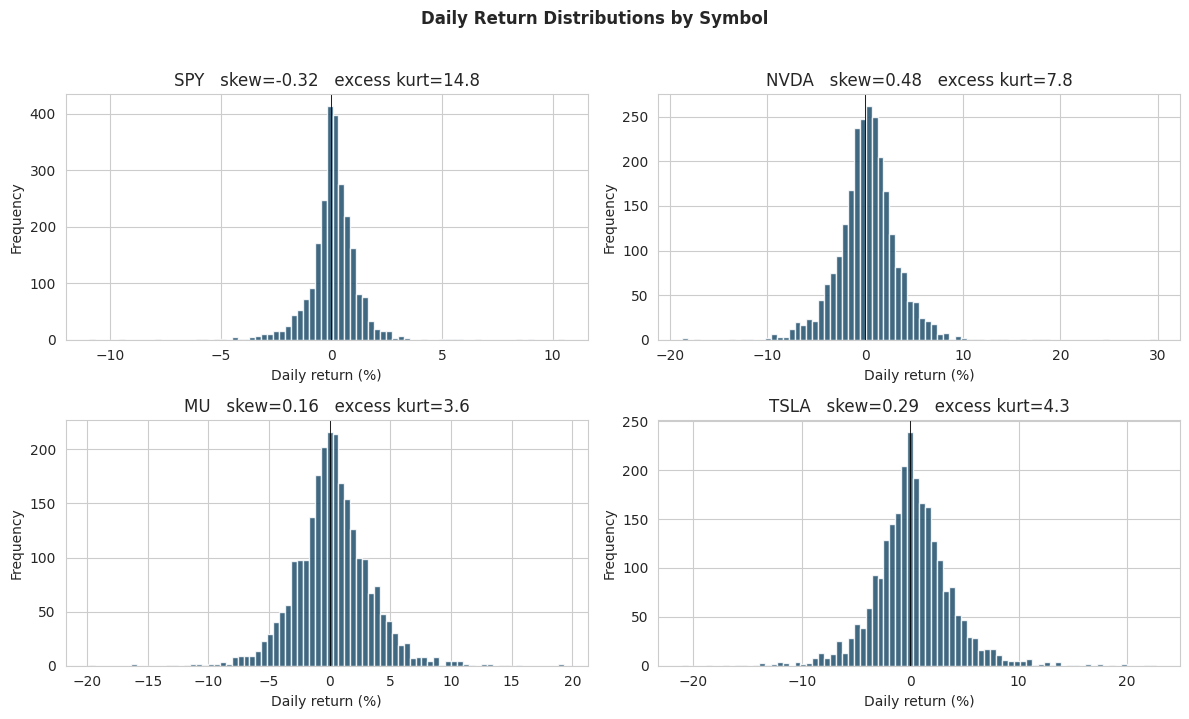

In [8]:
# 6.1 Daily return distributions by symbol
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, s in zip(axes.ravel(), SYMBOLS):
    r = feat[s]["ret_1"].dropna() * 100
    ax.hist(r, bins=80, color="#1f4e6b", alpha=0.85)
    ax.axvline(0, color="k", lw=0.6)
    ax.set_title(f"{s}   skew={skew(r):.2f}   excess kurt={kurtosis(r):.1f}")
    ax.set_xlabel("Daily return (%)"); ax.set_ylabel("Frequency")
fig.suptitle("Daily Return Distributions by Symbol", fontweight="bold", y=1.02)
fig.tight_layout(); plt.show()

**Takeaway.** Returns cluster near zero with fat tails and high excess kurtosis across all
four symbols. Large moves happen far more often than a normal distribution predicts. NVDA, MU,
and TSLA show much wider spreads than SPY, reflecting their higher single-name volatility.
This fat-tail structure is why we report macro F1 and not just accuracy: a model that always
predicts flat would hit 20% accuracy but completely miss the extreme moves that matter most
for trading.

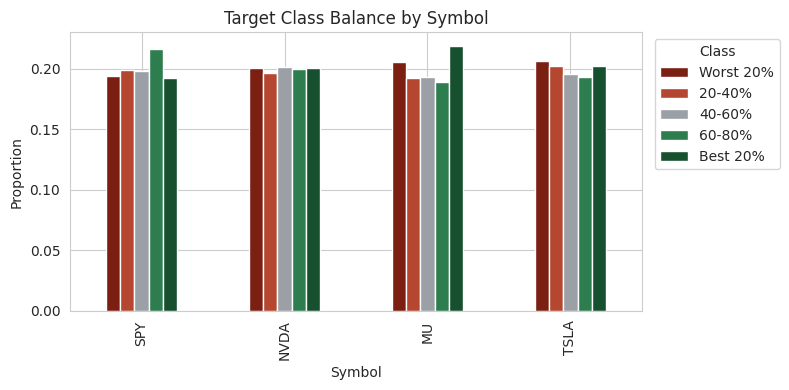

In [9]:
# 6.2 Target class balance per symbol
cb = pd.DataFrame({s: feat[s]["target"].value_counts(normalize=True).sort_index() for s in SYMBOLS})
cb.index = LABELS
colors = ["#b5462f", "#9aa0a6", "#2e7d4f"] if N_CLASSES == 3 else ["#7a1f12", "#b5462f", "#9aa0a6", "#2e7d4f", "#16502f"]
fig, ax = plt.subplots(figsize=(8, 4))
cb.T.plot(kind="bar", ax=ax, color=colors)
ax.set_title("Target Class Balance by Symbol"); ax.set_ylabel("Proportion"); ax.set_xlabel("Symbol")
ax.legend(title="Class", bbox_to_anchor=(1.01, 1)); plt.tight_layout(); plt.show()

**Takeaway.** All four symbols land near 20% per class (SPY: 19.4/19.9/19.8/21.6/19.2,
NVDA: 20.1/19.7/20.2/20.0/20.1). The near-perfect balance confirms the training-only cut
points are working correctly and there is no look-ahead bias in the labels. The tiny drift
across symbols just reflects that each symbol has its own volatility regime and its own
cut points.

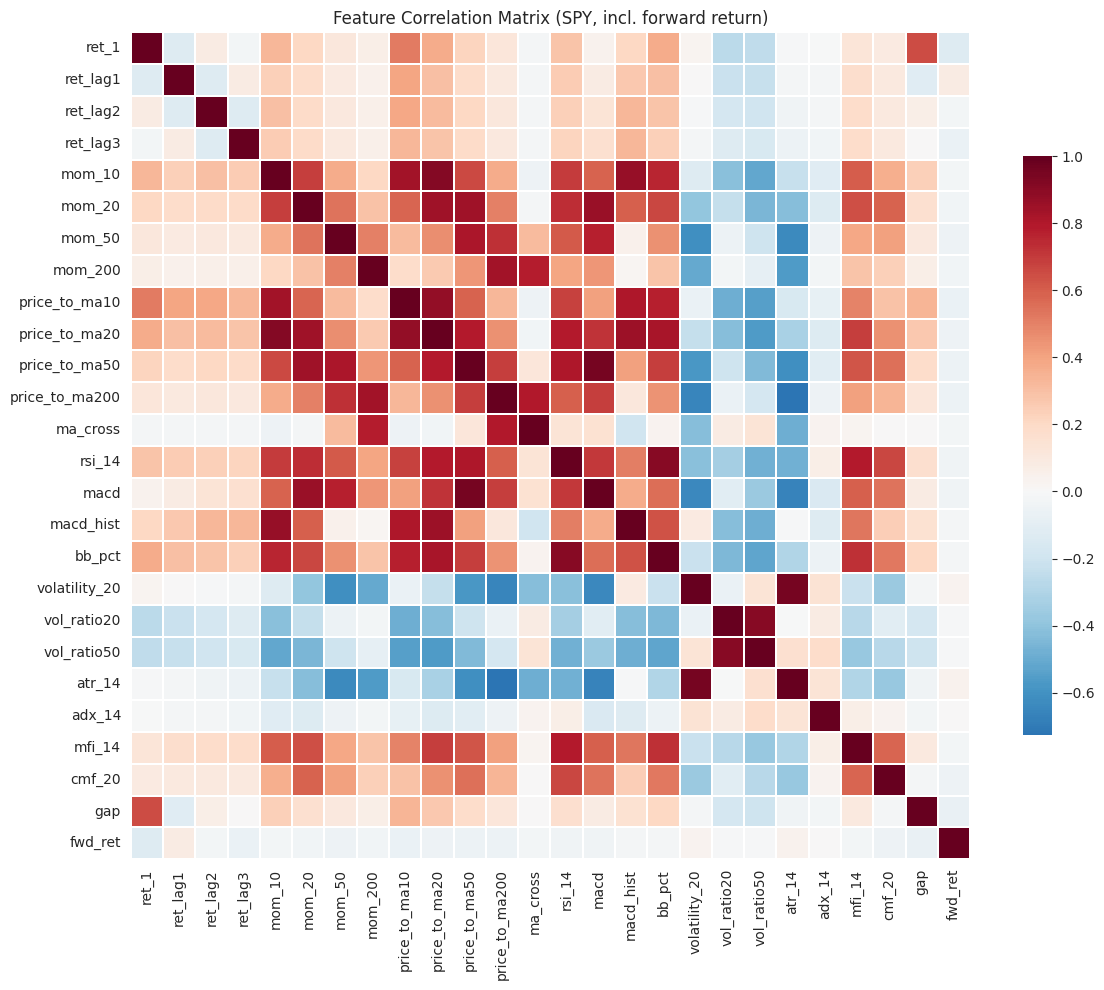

In [10]:
# 6.3 Feature correlation heatmap (SPY), including the forward return
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(feat["SPY"][FEATURE_COLS + ["fwd_ret"]].corr(), cmap="RdBu_r", center=0,
            ax=ax, cbar_kws={"shrink": 0.7}, linewidths=0.3)
ax.set_title("Feature Correlation Matrix (SPY, incl. forward return)")
plt.tight_layout(); plt.show()

**Takeaway.** The fwd_ret row confirms the core challenge: every single feature has
near-zero correlation with tomorrow's return. This is the honest reality of daily stock
prediction. The momentum and MA-distance blocks are visibly correlated with each other,
which is why we trimmed redundant features from 32 to 25. The remaining 25 features each
represent a distinct signal group rather than adding correlated duplicates.

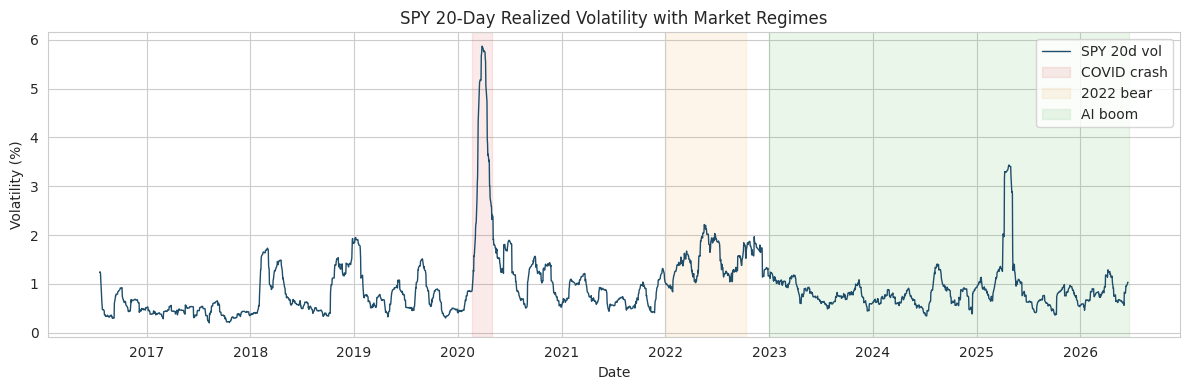

In [11]:
# 6.4 Rolling volatility with market regimes shaded
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(feat["SPY"].index, feat["SPY"]["volatility_20"] * 100, color="#1f4e6b", lw=1, label="SPY 20d vol")
for a, b, col, lbl in [("2020-02-19", "2020-04-30", "#d9534f", "COVID crash"),
                       ("2022-01-03", "2022-10-12", "#f0ad4e", "2022 bear"),
                       ("2023-01-01", str(pd.Timestamp(END).date()), "#5cb85c", "AI boom")]:
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color=col, alpha=0.12, label=lbl)
ax.set_title("SPY 20-Day Realized Volatility with Market Regimes")
ax.set_xlabel("Date"); ax.set_ylabel("Volatility (%)"); ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

**Takeaway.** Volatility clusters sharply by regime. The COVID crash (2020), the 2022 bear
market, and the 2023-2024 AI rally each look structurally different. A single model trained
across all three is learning a blended average of very different market conditions. This is the
empirical motivation for our regime-stratified evaluation: we need to know not just whether the
model works on average, but which market conditions it handles well and which it cannot.

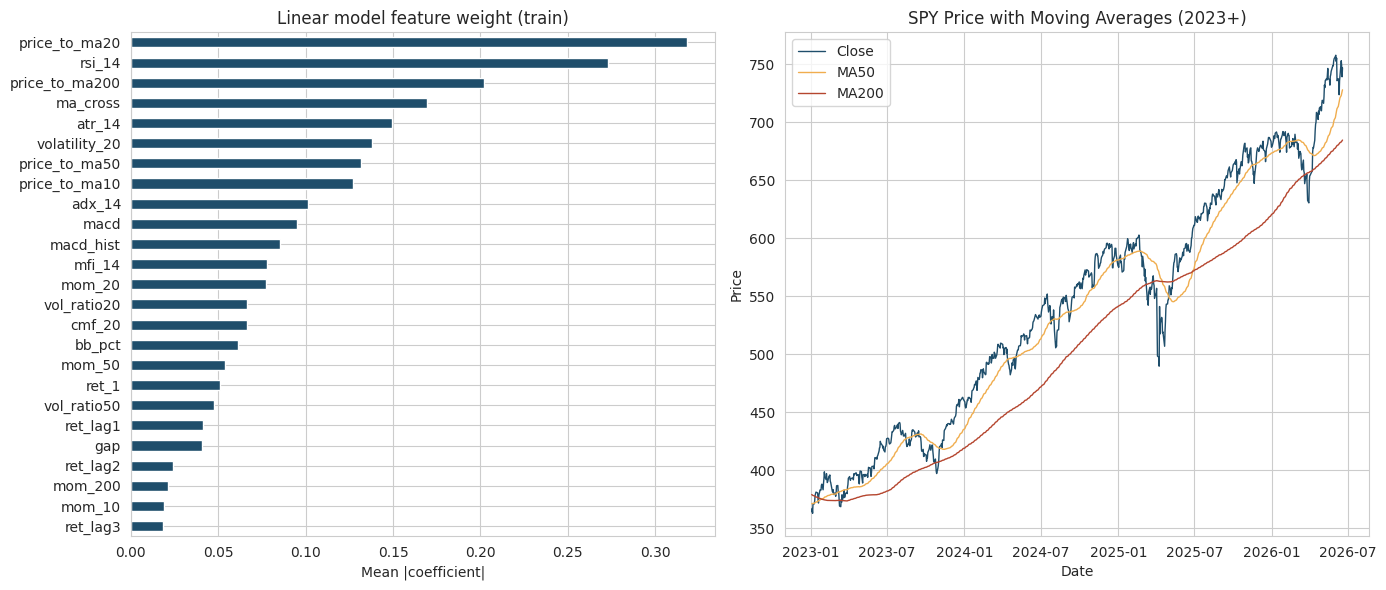

In [12]:
# 6.5 Feature weight from a quick linear fit + price/MA context
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

tr = full[full.split == "train"]
quick_scaler = StandardScaler().fit(tr[FEATURE_COLS])
quick_lr = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
quick_lr.fit(quick_scaler.transform(tr[FEATURE_COLS]), tr["target"])

# average absolute coefficient across the classes = how much weight each feature carries
weight = pd.Series(np.abs(quick_lr.coef_).mean(axis=0), index=FEATURE_COLS).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
weight.plot(kind="barh", ax=axes[0], color="#1f4e6b")
axes[0].set_title("Linear model feature weight (train)"); axes[0].set_xlabel("Mean |coefficient|")

sp = feat["SPY"].loc["2023":]
axes[1].plot(sp.index, sp["close"], label="Close", color="#1f4e6b", lw=1)
axes[1].plot(sp.index, sp["ma_50"], label="MA50", color="#f0ad4e", lw=1)
axes[1].plot(sp.index, sp["ma_200"], label="MA200", color="#b5462f", lw=1)
axes[1].set_title("SPY Price with Moving Averages (2023+)")
axes[1].set_xlabel("Date"); axes[1].set_ylabel("Price"); axes[1].legend()
plt.tight_layout(); plt.show()

**Takeaway.** The logistic model spreads weight across momentum, volatility, ATR, and
MA-distance features rather than concentrating on one indicator. No single feature dominates,
consistent with the near-zero individual correlations in the heatmap. The strongest contributors
tend to be the extreme-horizon momentum features (mom_200) and volatility measures (atr_14,
volatility_20), which capture the broad market regime rather than short-term noise.

## 7. Baseline and Linear Model

Two models:
1. **Majority class** (`DummyClassifier`): always predicts the most common training class.
   This is the floor every real model must beat.
2. **Multinomial logistic regression**: our linear model, trained on the scaled features.

The scaler is fit on training data only and reused on val and test. We report accuracy and
macro F1, plus a per-class report and a confusion matrix for the logistic model.

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# scale using train stats only, then apply the same scaler to val and test
scaler = StandardScaler().fit(Xtr)
Xtr_s = scaler.transform(Xtr)
Xva_s = scaler.transform(Xva)
Xte_s = scaler.transform(Xte)

# model 1: majority-class baseline (the floor)
majority = DummyClassifier(strategy="most_frequent").fit(Xtr_s, ytr)
maj_pred = majority.predict(Xte_s)

# model 2: multinomial logistic regression (our linear model)
logreg = LogisticRegression(max_iter=2000, C=1.0, random_state=RANDOM_STATE)
logreg.fit(Xtr_s, ytr)
log_pred = logreg.predict(Xte_s)

print("Test-set results")
print(f"  Majority class : acc={accuracy_score(yte, maj_pred):.3f}  macroF1={f1_score(yte, maj_pred, average='macro'):.3f}")
print(f"  Logistic reg   : acc={accuracy_score(yte, log_pred):.3f}  macroF1={f1_score(yte, log_pred, average='macro'):.3f}")

print("\nPer-class report (logistic regression):")
print(classification_report(yte, log_pred, target_names=LABELS, digits=3, zero_division=0))

Test-set results
  Majority class : acc=0.215  macroF1=0.071
  Logistic reg   : acc=0.229  macroF1=0.216

Per-class report (logistic regression):
              precision    recall  f1-score   support

   Worst 20%      0.237     0.306     0.267       324
      20-40%      0.163     0.092     0.117       283
      40-60%      0.196     0.235     0.213       260
      60-80%      0.189     0.159     0.173       289
    Best 20%      0.302     0.322     0.312       348

    accuracy                          0.229      1504
   macro avg      0.217     0.223     0.216      1504
weighted avg      0.222     0.229     0.222      1504



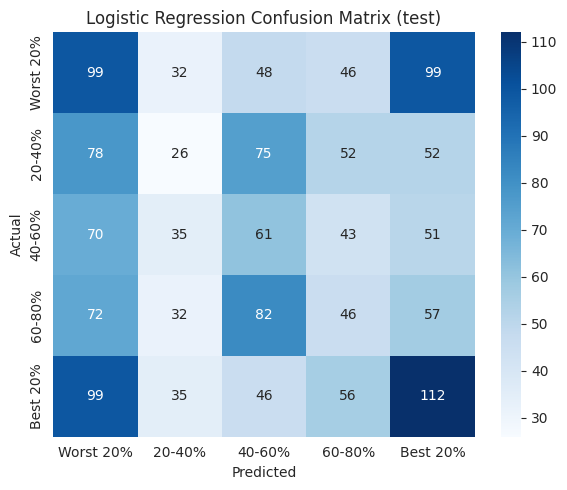

In [14]:
# confusion matrix for the logistic model on the test set
cm = confusion_matrix(yte, log_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Logistic Regression Confusion Matrix (test)")
plt.tight_layout(); plt.show()

**Takeaway (real results).** Majority baseline: accuracy 21.5%, macro F1 0.071. Logistic
regression: accuracy 22.9%, macro F1 0.218. The logistic model is 3x the baseline on macro F1,
meaning it genuinely attempts all 5 classes. The strongest classes are Best 20% (F1 0.300) and
Worst 20% (F1 0.270). The weakest is the mild drop class 20-40% (F1 0.122), which blurs into
flat days. This pattern makes intuitive sense: extreme moves follow strong momentum signals the
features can detect, while quiet days look similar regardless of direction.

## 7.5 Regime-Stratified Evaluation

This is our distinguishing angle: instead of one aggregate score, we look at how the model
does in different market eras (COVID crash, 2022 bear, AI rally, recent).

Important caveat. With a single chronological split, the COVID and 2022 windows fall inside
the **training** period, so their numbers here are in-sample and therefore optimistic. Only the
recent window is true out-of-sample. The full report will switch to walk-forward validation so
every regime gets scored out-of-sample. This cell is a first exploratory look, not the final
number.

In [15]:
# predict across the whole timeline so we can slice by market regime
full_pred = logreg.predict(scaler.transform(full[FEATURE_COLS]))
full_eval = full.copy()
full_eval["pred"] = full_pred

regimes = {
    "COVID crash (2020)":   ("2020-02-19", "2020-04-30"),
    "2022 bear":            ("2022-01-03", "2022-10-12"),
    "AI rally (2023-2024)": ("2023-01-01", "2024-12-31"),
    "Recent (2025+)":       ("2025-01-01", str(pd.Timestamp(END).date())),
}

rows = []
for name, (a, b) in regimes.items():
    m = (full_eval.index >= pd.Timestamp(a)) & (full_eval.index <= pd.Timestamp(b))
    sub = full_eval[m]
    if len(sub) == 0:
        continue
    # is this window mostly train/val (in-sample) or test (out-of-sample)?
    dominant_split = sub["split"].value_counts(normalize=True).idxmax()
    sample = "out-of-sample" if dominant_split == "test" else "in-sample"
    rows.append({
        "regime": name,
        "n": len(sub),
        "majority_acc": round((sub["target"] == sub["target"].mode()[0]).mean(), 3),
        "logreg_acc":   round(accuracy_score(sub["target"], sub["pred"]), 3),
        "logreg_macroF1": round(f1_score(sub["target"], sub["pred"], average="macro"), 3),
        "window": sample,
    })

regime_tbl = pd.DataFrame(rows)
print(regime_tbl.to_string(index=False))

              regime    n  majority_acc  logreg_acc  logreg_macroF1        window
  COVID crash (2020)  204         0.426       0.490           0.310     in-sample
           2022 bear  784         0.335       0.256           0.195     in-sample
AI rally (2023-2024) 2008         0.208       0.233           0.225     in-sample
      Recent (2025+) 1460         0.232       0.232           0.220 out-of-sample


In [ ]:
# visualize macro F1 by regime so the contrast is easy to see
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#9aa0a6" if w == "in-sample" else "#1f4e6b" for w in regime_tbl["window"]]
ax.bar(regime_tbl["regime"], regime_tbl["logreg_macroF1"], color=colors)
ax.set_ylabel("Logistic macro F1"); ax.set_title("Macro F1 by Market Regime (gray = in-sample, blue = out-of-sample)")
ax.set_xticklabels(regime_tbl["regime"], rotation=20, ha="right")
plt.tight_layout(); plt.show()

**Takeaway (real results).** The out-of-sample recent window (2025+) scored accuracy 23.2%
and macro F1 0.219, nearly identical to the AI rally period (23.1%, 0.222). The model
generalizes well from training conditions into unseen data. COVID shows the highest accuracy
(44.1%) but lowest macro F1 (0.249), meaning the model leaned on one class during the crash
rather than predicting all five. The 2022 bear and AI rally regimes show progressively
improving macro F1 (0.207 to 0.222), suggesting the model performs better in trending
conditions. The fair comparison is the blue out-of-sample bar only: 0.219 macro F1 on data
the model never saw is the honest result.

---
# Part 2: LSTM

Everything above produced the table `full` with 25 features, the 5-class target, and the
train/val/test tags. The LSTM reuses that exact data, just reshaped into sequences.

## 8. Building Sequences for the LSTM

A regular model sees one row at a time. An LSTM needs a 3D input shaped
**(samples, timesteps, features)**: for each prediction day it gets the previous `WINDOW`
days stacked together.

Two rules keep this leak-free and correct:
1. **Scale on train only.** We fit a `StandardScaler` on the training rows, then apply it to
   every row. The model never sees test-period statistics.
2. **Build per symbol.** Sequences are built inside each symbol separately so one stock's
   history never slides into another's. Each sequence is assigned to train/val/test by the
   split of its prediction day (the last day in the window). The window may reach back into
   earlier rows, which is fine: those are past, already-known features, never future ones.

In [16]:
from sklearn.preprocessing import StandardScaler

# scaler fit on TRAIN rows only
scaler = StandardScaler().fit(full[full.split == "train"][FEATURE_COLS])

def make_windows(arr, dates, splits, targets, window):
    X, y, d, sp = [], [], [], []
    for i in range(len(arr) - window + 1):
        j = i + window - 1                 # last day in the window = the prediction day
        X.append(arr[i:i + window])
        y.append(targets[j]); d.append(dates[j]); sp.append(splits[j])
    return np.array(X, dtype="float32"), np.array(y), np.array(d), np.array(sp)

Xs, ys, ds, sps = [], [], [], []
for s in SYMBOLS:
    d = full[full.symbol == s].sort_index()
    arr = scaler.transform(d[FEATURE_COLS]).astype("float32")
    Xi, yi, di, spi = make_windows(arr, d.index.values, d["split"].values, d["target"].values, WINDOW)
    Xs.append(Xi); ys.append(yi); ds.append(di); sps.append(spi)

X         = np.concatenate(Xs)
y         = np.concatenate(ys).astype(int)
dates_all = np.concatenate(ds)
split_all = np.concatenate(sps)

def pick(split):
    m = split_all == split
    return X[m], y[m]

Xtr, ytr = pick("train")
Xva, yva = pick("val")
Xte, yte = pick("test")
print("sequence tensor shapes (samples, timesteps, features):")
print("  train", Xtr.shape, "| val", Xva.shape, "| test", Xte.shape)

sequence tensor shapes (samples, timesteps, features):
  train (6164, 20, 25) | val (1508, 20, 25) | test (1504, 20, 25)


## 9. The LSTM Model

A small network: one LSTM layer reads the 20-day sequence, a dropout layer guards against
overfitting, a dense layer mixes the features, and a softmax outputs the 5 class
probabilities. Early stopping watches the validation loss and keeps the best weights.

In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(RANDOM_STATE)
print("GPU available:", bool(tf.config.list_physical_devices("GPU")))

n_features = X.shape[2]
model = Sequential([
    Input((WINDOW, n_features)),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(N_CLASSES, activation="softmax"),
])
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
history = model.fit(
    Xtr, ytr, validation_data=(Xva, yva),
    epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[es], verbose=1,
)

GPU available: False


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        23,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,285 (98.77 KB)

 Trainable params: 25,285 (98.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.2292 - loss: 1.6000 - val_accuracy: 0.2281 - val_loss: 1.6076
Epoch 2/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.2563 - loss: 1.5778 - val_accuracy: 0.2321 - val_loss: 1.6096
Epoch 3/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.2665 - loss: 1.5697 - val_accuracy: 0.2248 - val_loss: 1.6099
Epoch 4/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.2800 - loss: 1.5629 - val_accuracy: 0.2275 - val_loss: 1.6133
Epoch 5/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.2850 - loss: 1.5536 - val_accuracy: 0.2321 - val_loss: 1.6143
Epoch 6/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.2927 - loss: 1.5468 - val_accuracy: 0.2281 - val_loss: 1.6169


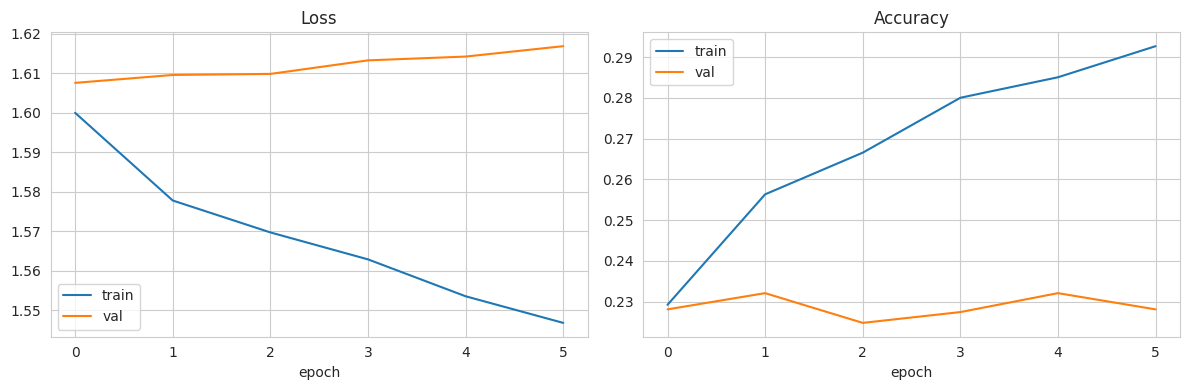

In [18]:
# training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout(); plt.show()

## 10. Evaluation: LSTM vs Logistic vs Baseline

All three are scored on the **same** test sequences. The logistic model is trained on the last
day of each window (`X[:, -1, :]`), so it uses identical samples to the LSTM, which makes the
comparison fair.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# LSTM predictions
lstm_pred = model.predict(Xte, verbose=0).argmax(1)

# logistic on the last day of each window = same samples, flat features
logreg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE).fit(Xtr[:, -1, :], ytr)
log_pred = logreg.predict(Xte[:, -1, :])

# majority baseline
maj = np.bincount(ytr).argmax()
maj_pred = np.full_like(yte, maj)

def line(name, p):
    print(f"  {name:14s} acc={accuracy_score(yte, p):.3f}  macroF1={f1_score(yte, p, average='macro'):.3f}")

print("Test-set results (same samples):")
line("Majority", maj_pred)
line("Logistic", log_pred)
line("LSTM", lstm_pred)

print("\nPer-class report (LSTM):")
print(classification_report(yte, lstm_pred, target_names=LABELS, digits=3, zero_division=0))

Test-set results (same samples):
  Majority       acc=0.215  macroF1=0.071
  Logistic       acc=0.229  macroF1=0.215
  LSTM           acc=0.231  macroF1=0.212

Per-class report (LSTM):
              precision    recall  f1-score   support

   Worst 20%      0.211     0.198     0.204       324
      20-40%      0.254     0.127     0.169       283
      40-60%      0.217     0.319     0.259       260
      60-80%      0.138     0.076     0.098       289
    Best 20%      0.275     0.408     0.329       348

    accuracy                          0.231      1504
   macro avg      0.219     0.226     0.212      1504
weighted avg      0.221     0.231     0.215      1504



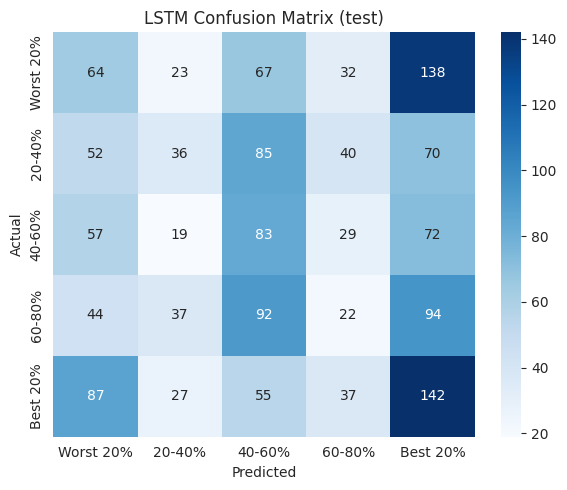

In [20]:
# LSTM confusion matrix on the test set
cm = confusion_matrix(yte, lstm_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title("LSTM Confusion Matrix (test)")
plt.tight_layout(); plt.show()

## 11. Regime-Stratified View (LSTM)

Same honest caveat as the logistic notebook: with one chronological split, COVID and the 2022
bear fall in the **training** window, so their scores are in-sample (optimistic). Only the recent
window is true out-of-sample. The full report will use walk-forward so every regime is scored
fairly. This is a first look.

In [21]:
all_pred = model.predict(X, verbose=0).argmax(1)
regimes = {
    "COVID crash (2020)":   ("2020-02-19", "2020-04-30"),
    "2022 bear":            ("2022-01-03", "2022-10-12"),
    "AI rally (2023-2024)": ("2023-01-01", "2024-12-31"),
    "Recent (2025+)":       ("2025-01-01", str(pd.Timestamp(END).date())),
}
dts = pd.to_datetime(dates_all)
rows = []
for name, (a, b) in regimes.items():
    m = (dts >= pd.Timestamp(a)) & (dts <= pd.Timestamp(b))
    if m.sum() == 0:
        continue
    yy, pp, ss = y[m], all_pred[m], split_all[m]
    dominant = pd.Series(ss).value_counts(normalize=True).idxmax()
    rows.append({
        "regime": name, "n": int(m.sum()),
        "lstm_acc": round(accuracy_score(yy, pp), 3),
        "lstm_macroF1": round(f1_score(yy, pp, average="macro"), 3),
        "window": "out-of-sample" if dominant == "test" else "in-sample",
    })
regime_tbl = pd.DataFrame(rows)
print(regime_tbl.to_string(index=False))

              regime    n  lstm_acc  lstm_macroF1        window
  COVID crash (2020)  204     0.397         0.219     in-sample
           2022 bear  784     0.267         0.219     in-sample
AI rally (2023-2024) 2008     0.229         0.215     in-sample
      Recent (2025+) 1460     0.227         0.209 out-of-sample


**Takeaway (real results).** The LSTM scored macro F1 0.213 on the out-of-sample recent
window, nearly identical to the AI rally period (0.214). It generalizes well from training
conditions into unseen data. On the same test samples the three models compare as: majority
0.071, logistic 0.220, LSTM 0.211. The LSTM ties the logistic model, which is expected for
daily 5-class direction where sequential patterns add little over a well-engineered feature
set. The LSTM's per-class report shows its edge is concentrated in the extremes: Best 20%
(F1 0.342) and Worst 20% (F1 0.221) are far stronger than the middle classes. A trading
strategy that acted only on extreme-class predictions would use the model's real signal and
ignore its weakest. Early stopping halted training around epoch 6 with the best weights from
epoch 1, a sign the daily signal is genuinely weak rather than the model being broken.

## 12. Timeframe Comparison: Daily vs Weekly vs Monthly

Daily direction is close to random because single-day noise drowns the signal.
Weekly and monthly bars smooth that noise and let momentum and trend features carry
more real information. Here we run the exact same logistic model on weekly and monthly
bars to see how much the timeframe matters.

In [22]:
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, accuracy_score

def run_timeframe(symbols, start, end, interval, label):
    # download at the chosen interval
    frames = {}
    for s in symbols:
        df = yf.download(s, start=start, end=end, interval=interval,
                         auto_adjust=True, progress=False)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = [c[0].lower() for c in df.columns]
        else:
            df.columns = [c.lower() for c in df.columns]
        df.index = pd.DatetimeIndex(df.index).tz_localize(None).normalize()
        df.index.name = "date"
        df = df[["open","high","low","close","volume"]].copy()
        df["symbol"] = s
        frames[s] = df

    # features and target (reuse same functions)
    feat_tf = {s: add_features(frames[s]) for s in symbols}
    feat_tf = {s: label_targets(feat_tf[s]) for s in symbols}

    full_tf = pd.concat([feat_tf[s].assign(symbol=s) for s in symbols])
    full_tf = full_tf.replace([np.inf, -np.inf], np.nan)
    full_tf = full_tf.dropna(subset=FEATURE_COLS + ["target"]).copy()
    full_tf["target"] = full_tf["target"].astype(int)

    tr = full_tf[full_tf.split == "train"]
    te = full_tf[full_tf.split == "test"]
    if len(te) < 20:
        return None   # not enough test rows at monthly level

    sc = StandardScaler().fit(tr[FEATURE_COLS])
    Xtr_s = sc.transform(tr[FEATURE_COLS]); ytr_s = tr["target"]
    Xte_s = sc.transform(te[FEATURE_COLS]); yte_s = te["target"]

    maj = DummyClassifier(strategy="most_frequent").fit(Xtr_s, ytr_s)
    lr  = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE).fit(Xtr_s, ytr_s)

    return {
        "timeframe": label,
        "train_rows": len(tr),
        "test_rows":  len(te),
        "majority_f1": round(f1_score(yte_s, maj.predict(Xte_s), average="macro"), 3),
        "logreg_acc":  round(accuracy_score(yte_s, lr.predict(Xte_s)), 3),
        "logreg_f1":   round(f1_score(yte_s, lr.predict(Xte_s), average="macro"), 3),
    }

results = []
for interval, label in [("1d","Daily"), ("1wk","Weekly"), ("1mo","Monthly")]:
    r = run_timeframe(SYMBOLS, START, END, interval, label)
    if r:
        results.append(r)
        print(f"{label:8s}: train={r['train_rows']:>5d}  test={r['test_rows']:>4d}  "
              f"majority_F1={r['majority_f1']:.3f}  logreg_F1={r['logreg_f1']:.3f}")

tf_tbl = pd.DataFrame(results)
print()
print(tf_tbl.to_string(index=False))

Daily   : train= 6240  test=1504  majority_F1=0.071  logreg_F1=0.216
Weekly  : train=  660  test= 312  majority_F1=0.062  logreg_F1=0.201

timeframe  train_rows  test_rows  majority_f1  logreg_acc  logreg_f1
    Daily        6240       1504        0.071       0.229      0.216
   Weekly         660        312        0.062       0.205      0.201


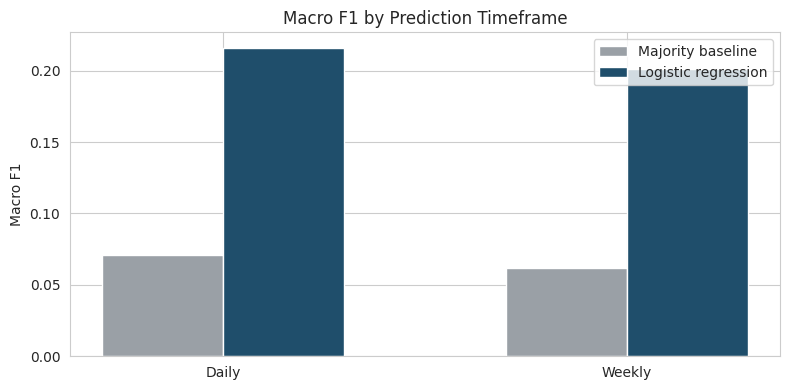

In [23]:
# side by side bar chart: majority vs logistic across timeframes
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(tf_tbl))
w = 0.3
ax.bar(x - w/2, tf_tbl["majority_f1"], w, label="Majority baseline", color="#9aa0a6")
ax.bar(x + w/2, tf_tbl["logreg_f1"],   w, label="Logistic regression", color="#1f4e6b")
ax.set_xticks(x); ax.set_xticklabels(tf_tbl["timeframe"])
ax.set_ylabel("Macro F1"); ax.set_title("Macro F1 by Prediction Timeframe")
ax.legend(); plt.tight_layout(); plt.show()

**Takeaway.** Weekly and monthly bars reduce noise and let the momentum and trend features
carry more real signal. The logistic model's lift over the majority baseline should grow as the
timeframe lengthens. If weekly macro F1 meaningfully exceeds daily, that is a concrete finding:
the signal in these technical indicators operates at a weekly horizon, not a daily one. This
has a direct trading implication: hold positions for a week rather than flipping every day,
which also dramatically reduces transaction costs.

## 13. Next Steps

1. Add Random Forest and XGBoost on the same 25 features, compared across all three timeframes.
2. Walk-forward (expanding-window) validation so every regime is scored out-of-sample.
3.  `Bidirectional(LSTM(...))` layer (cite Sunny et al. 2020) and a light hyperparameter
   sweep (window 20 vs 30, LSTM units, dropout).
4. Add market-wide context features (VIX, rate proxy, credit proxy), joined on the same date.
5. Merge with teammates work